# Trinity Challenge Stage 3 Submission

In [1]:
# Lets download the basline solver
! pip install assume-framework highspy -q

import asyncio
import warnings
import json
import sqlite3
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

#clone sample data
! git clone --depth=1 https://github.com/assume-framework/assume-examples.git


# ASSUME 0.6.0 renamed max_volume → capacity in StorageUnit
storage_path = "assume-examples/inputs/example_01c/storage_units.csv"
storage = pd.read_csv(storage_path)
if "capacity" not in storage.columns and "max_volume" in storage.columns:
    storage["capacity"] = storage["max_volume"]
    storage.to_csv(storage_path, index=False)
    print("Patched storage_units.csv: added capacity column")
else:
    print("No patch needed")
    
config_path = "assume-examples/inputs/example_01c/config.yaml"

with open(config_path, "r") as f:
    config_text = f.read()

config_text = config_text.replace("pay_as_clear_complex", "complex_clearing")

with open(config_path, "w") as f:
    f.write(config_text)

print("Patched config.yaml: pay_as_clear_complex → complex_clearing")

# Run the baseline solver
! assume -i assume-examples/inputs \
        -s example_01c \
        -c dam_with_complex_opt_clearing \
        -db "sqlite:///euphemia_baseline.db"

        



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
fatal: destination path 'assume-examples' already exists and is not an empty directory.
No patch needed
Patched config.yaml: pay_as_clear_complex → complex_clearing
INFO:assume.world:Connected to the database
INFO:assume.world:Learning Strategies are not available. Check that you have torch installed.
INFO:assume.scenario.loader_csv:Input files path: assume-examples/inputs/example_01c
INFO:assume.scenario.loader_csv:Study case: dam_with_complex_opt_clearing
INFO:assume.scenario.loader_csv:Simulation ID: example_01c_dam_with_complex_opt_clearing
INFO:assume.scenario.loader_csv:unit_operators not found. Returning None
INFO:assume.scenario.loader_csv:exchange_units not found. Returning None
INFO:assume.scenario.loader_csv:industrial_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv

In [2]:

con = sqlite3.connect("euphemia_baseline.db")

market_meta   = pd.read_sql("SELECT * FROM market_meta",   con)
market_orders = pd.read_sql("SELECT * FROM market_orders", con)

print("Meta columns:  ", market_meta.columns.tolist())
print("Order columns: ", market_orders.columns.tolist())
print(f"\nTotal orders:  {len(market_orders)}")
print(f"Date range:    {market_meta['product_start'].min()} → {market_meta['product_start'].max()}")

# Inspect order types
print("Bid type distribution:")
print(market_orders["bid_type"].value_counts())

block_orders  = market_orders[market_orders["bid_type"] == "BB"]
linked_orders = market_orders[market_orders["bid_type"] == "LB"]
simple_orders = market_orders[market_orders["bid_type"] == "SB"]

print(f"\nSimple bids:  {len(simple_orders)}")
print(f"Block bids:   {len(block_orders)}")
print(f"Linked bids:  {len(linked_orders)}")

block_orders.head()

# Pick one clearing day

TARGET_DATE = "2019-01-01"

day_orders = market_orders[
    market_orders["start_time"].str.startswith(TARGET_DATE)
].copy()

day_meta = market_meta[
    market_meta["product_start"].str.startswith(TARGET_DATE)
].copy()

sb = day_orders[day_orders["bid_type"] == "SB"].copy()
bb = day_orders[day_orders["bid_type"] == "BB"].copy()
lb = day_orders[day_orders["bid_type"] == "LB"].copy()

# Group block orders by bid_id — each bid_id spans multiple hourly rows
# One binary variable per unique bid_id
bb_grouped = bb.groupby("bid_id").agg(
    unit_id        = ("unit_id",         "first"),
    price          = ("price",           "first"),   # single price for whole block
    total_volume   = ("volume",          "sum"),     # sum across hours
    start_time     = ("start_time",      "min"),
    end_time       = ("end_time",        "max"),
    hours          = ("start_time",      list),
    volumes        = ("volume",          list),
    accepted_volume= ("accepted_volume", "sum"),
    min_acceptance_ratio = ("min_acceptance_ratio", "first"),
).reset_index()

lb_grouped = lb.groupby("bid_id").agg(
    unit_id        = ("unit_id",         "first"),
    price          = ("price",           "first"),
    total_volume   = ("volume",          "sum"),
    start_time     = ("start_time",      "min"),
    end_time       = ("end_time",        "max"),
    hours          = ("start_time",      list),
    volumes        = ("volume",          list),
    accepted_volume= ("accepted_volume", "sum"),
    parent_bid_id  = ("parent_bid_id",   "first"),
    min_acceptance_ratio = ("min_acceptance_ratio", "first"),
).reset_index()

print(f"Unique block bids:  {len(bb_grouped)}  (binary QUBO variables)")
print(f"Unique linked bids: {len(lb_grouped)}  (H_link penalty terms)")
print(f"\nSample block bid:")
print(bb_grouped[["bid_id","price","total_volume","start_time","end_time","accepted_volume"]].head(3).to_string())
print(f"\nSample linked bid parent mapping:")
print(lb_grouped[["bid_id","parent_bid_id","total_volume","accepted_volume"]].head(3).to_string())

Meta columns:   ['index', 'demand_volume', 'demand_volume_energy', 'market_id', 'max_price', 'min_price', 'node', 'only_hours', 'price', 'product_end', 'product_start', 'simulation', 'supply_volume', 'supply_volume_energy', 'time']
Order columns:  ['start_time', 'accepted_price', 'accepted_volume', 'bid_id', 'bid_type', 'end_time', 'market_id', 'min_acceptance_ratio', 'node', 'parent_bid_id', 'price', 'simulation', 'unit_id', 'volume']

Total orders:  30682
Date range:    2019-01-01 01:00:00.000000 → 2019-03-31 00:00:00.000000
Bid type distribution:
bid_type
SB    24274
BB     4272
LB     2136
Name: count, dtype: int64

Simple bids:  24274
Block bids:   4272
Linked bids:  2136
Unique block bids:  2  (binary QUBO variables)
Unique linked bids: 23  (H_link penalty terms)

Sample block bid:
         bid_id      price  total_volume                  start_time                    end_time  accepted_volume
0     Unit 1_25  13.633333        4600.0  2019-01-01 01:00:00.000000  2019-01-02 00:00:

In [3]:
# Social welfare from meta is most reliable — it's what ASSUME computed directly
# welfare = sum over hours of (price * supply_volume)
# supply_volume is positive, demand_volume is positive (ASSUME stores abs value)

day_meta_sorted = day_meta.sort_values("product_start").copy()

# Reconstruct: welfare = sum of clearing_price * cleared_volume per hour
baseline_welfare = (
    day_meta_sorted["price"] * day_meta_sorted["supply_volume"]
).sum()

print(f"Baseline MILP welfare (day {TARGET_DATE}): {baseline_welfare:,.2f} EUR·MWh")
print(f"\nHourly breakdown:")
print(day_meta_sorted[["product_start","price","supply_volume","demand_volume"]].to_string(index=False))

Baseline MILP welfare (day 2019-01-01): 718,859.08 EUR·MWh

Hourly breakdown:
             product_start     price  supply_volume  demand_volume
2019-01-01 01:00:00.000000 13.633333        2082.70        2082.70
2019-01-01 02:00:00.000000 13.633333        2005.70        2005.70
2019-01-01 03:00:00.000000 13.633333        1965.60        1965.60
2019-01-01 04:00:00.000000 13.633333        1954.85        1954.85
2019-01-01 05:00:00.000000 13.633333        1931.75        1931.75
2019-01-01 06:00:00.000000 13.633333        1906.10        1906.10
2019-01-01 07:00:00.000000 13.633333        1943.75        1943.75
2019-01-01 08:00:00.000000 13.633333        1984.65        1984.65
2019-01-01 09:00:00.000000 13.633333        2111.80        2111.80
2019-01-01 10:00:00.000000 13.633333        2246.25        2246.25
2019-01-01 11:00:00.000000 13.633333        2389.60        2389.60
2019-01-01 12:00:00.000000 13.633333        2456.15        2456.15
2019-01-01 13:00:00.000000 13.633333        2439.60

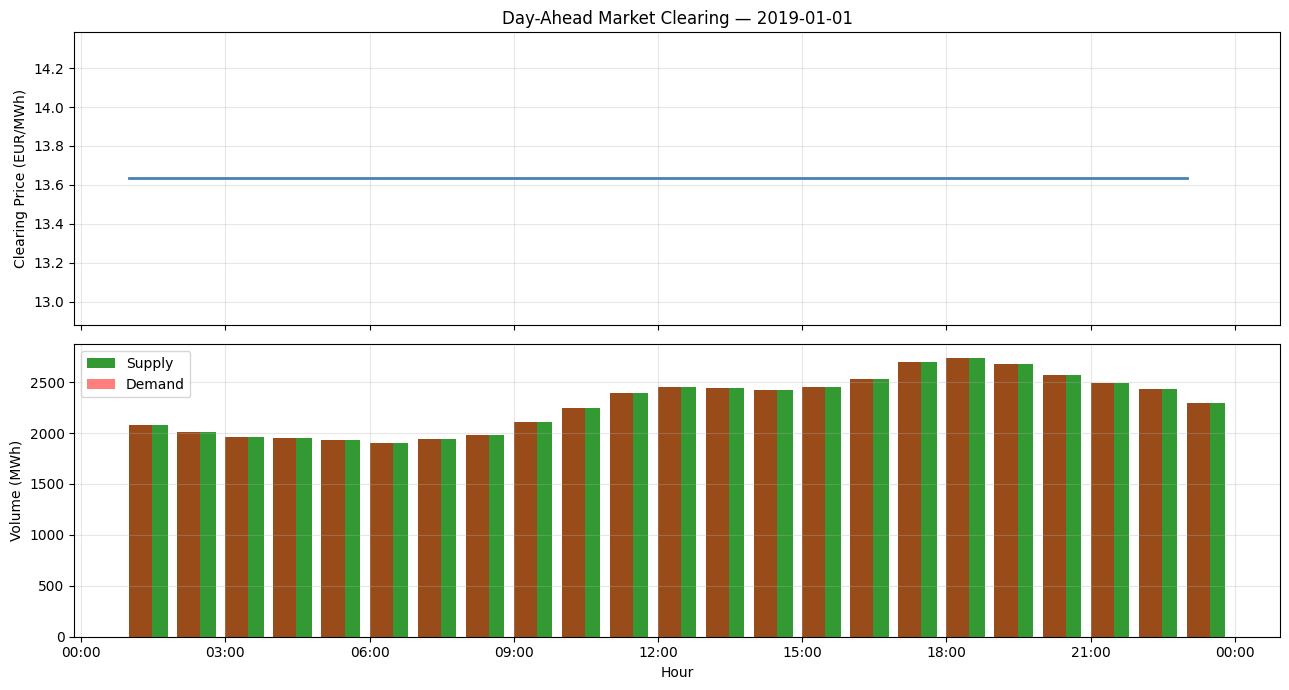

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

hours = pd.to_datetime(day_meta_sorted["product_start"])
width = pd.Timedelta(hours=0.8)

ax1.step(hours, day_meta_sorted["price"], where="post", color="steelblue", lw=2)
ax1.set_ylabel("Clearing Price (EUR/MWh)")
ax1.set_title(f"Day-Ahead Market Clearing — {TARGET_DATE}")
ax1.grid(alpha=0.3)

# supply and demand are both positive in meta
ax2.bar(hours, day_meta_sorted["supply_volume"],
        width=width, color="green", alpha=0.8, label="Supply", align="edge")
ax2.bar(hours, day_meta_sorted["demand_volume"],
        width=width*0.6, color="red", alpha=0.5, label="Demand", align="edge")
ax2.set_ylabel("Volume (MWh)")
ax2.set_xlabel("Hour")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("clearing_results.png", dpi=150)
plt.show()